In [1]:
# Cell 1: Import required packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, simpson
from scipy.interpolate import interp1d
from scipy.special import spherical_jn
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib style
#plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✓ Packages imported successfully")
print(f"  - NumPy version: {np.__version__}")
print(f"  - Matplotlib backend: {plt.get_backend()}")

✓ Packages imported successfully
  - NumPy version: 1.26.4
  - Matplotlib backend: module://matplotlib_inline.backend_inline


In [2]:
# Cell 2: Define cosmological parameters (Planck 2015-like)
class CosmologicalParameters:
    """Fiducial cosmological parameters"""
    def __init__(self):
        # Hubble parameter
        self.h = 0.6774  # H0 = 67.74 km/s/Mpc
        self.H0 = self.h * 100  # km/s/Mpc
        
        # Densities
        self.Omega_m = 0.3089  # Matter density
        self.Omega_Lambda = 0.6911  # Dark energy density
        self.Omega_b = 0.0486  # Baryon density
        self.Omega_c = self.Omega_m - self.Omega_b  # CDM density
        
        # Other parameters
        self.T_CMB = 2.7255  # CMB temperature in Kelvin
        self.n_s = 0.9667  # Scalar spectral index
        self.sigma_8 = 0.8159  # Matter fluctuation amplitude
        self.tau_reion = 0.066  # Optical depth to reionization
        
        # Speed of light
        self.c = 299792.458  # km/s
        
        # Reionization parameters
        self.z_reion = 8.8  # Reionization redshift
        self.Delta_z_reion = 1.0  # Reionization width

cosmo = CosmologicalParameters()

print("✓ Cosmological parameters initialized")
print(f"  - h = {cosmo.h}")
print(f"  - Ω_m = {cosmo.Omega_m}")
print(f"  - Ω_Λ = {cosmo.Omega_Lambda}")
print(f"  - T_CMB = {cosmo.T_CMB} K")
print(f"  - z_reion = {cosmo.z_reion}")

✓ Cosmological parameters initialized
  - h = 0.6774
  - Ω_m = 0.3089
  - Ω_Λ = 0.6911
  - T_CMB = 2.7255 K
  - z_reion = 8.8


In [3]:
# Cell 3: Cosmological distance functions
def H(z, cosmo):
    """Hubble parameter as a function of redshift [km/s/Mpc]"""
    return cosmo.H0 * np.sqrt(cosmo.Omega_m * (1+z)**3 + cosmo.Omega_Lambda)

def comoving_distance(z, cosmo):
    """Comoving distance to redshift z [Mpc]"""
    if np.isscalar(z):
        result, _ = quad(lambda zp: cosmo.c / H(zp, cosmo), 0, z)
        return result
    else:
        return np.array([comoving_distance(zi, cosmo) for zi in z])

def growth_function(z, cosmo):
    """Linear growth function D(z), normalized to D(z) = 1/(1+z) at high z"""
    # Approximate formula for flat LCDM
    Omega_m_z = cosmo.Omega_m * (1+z)**3 / (cosmo.Omega_m * (1+z)**3 + cosmo.Omega_Lambda)
    Omega_L_z = 1 - Omega_m_z
    
    # Carroll, Press & Turner (1992) approximation
    g = 2.5 * Omega_m_z / (Omega_m_z**(4/7) - Omega_L_z + (1 + Omega_m_z/2) * (1 + Omega_L_z/70))
    
    # Normalize to high-z behavior
    g_norm = g / (1 + z)
    return g_norm

# Test functions
z_test = np.array([0, 1, 2, 5, 10])
print("\n✓ Cosmological functions defined")
print("\nTest values:")
print(f"  z = {z_test}")
print(f"  H(z) [km/s/Mpc] = {H(z_test, cosmo)}")
print(f"  χ(z) [Mpc] = {comoving_distance(z_test, cosmo)}")
print(f"  D(z) = {growth_function(z_test, cosmo)}")


✓ Cosmological functions defined

Test values:
  z = [ 0  1  2  5 10]
  H(z) [km/s/Mpc] = [  67.74        120.46107273  203.57419733  556.18417794 1374.69981154]
  χ(z) [Mpc] = [   0.         3396.21097084 5312.37825138 7957.54204496 9653.18082746]
  D(z) = [0.783372   0.47764129 0.32854488 0.16635743 0.09088161]



Computing optical depth τ(z)...
✓ Optical depth computation complete

Total optical depth τ(z=0 to z=20) = 0.0698
Expected ~0.0660
Ratio: 1.06


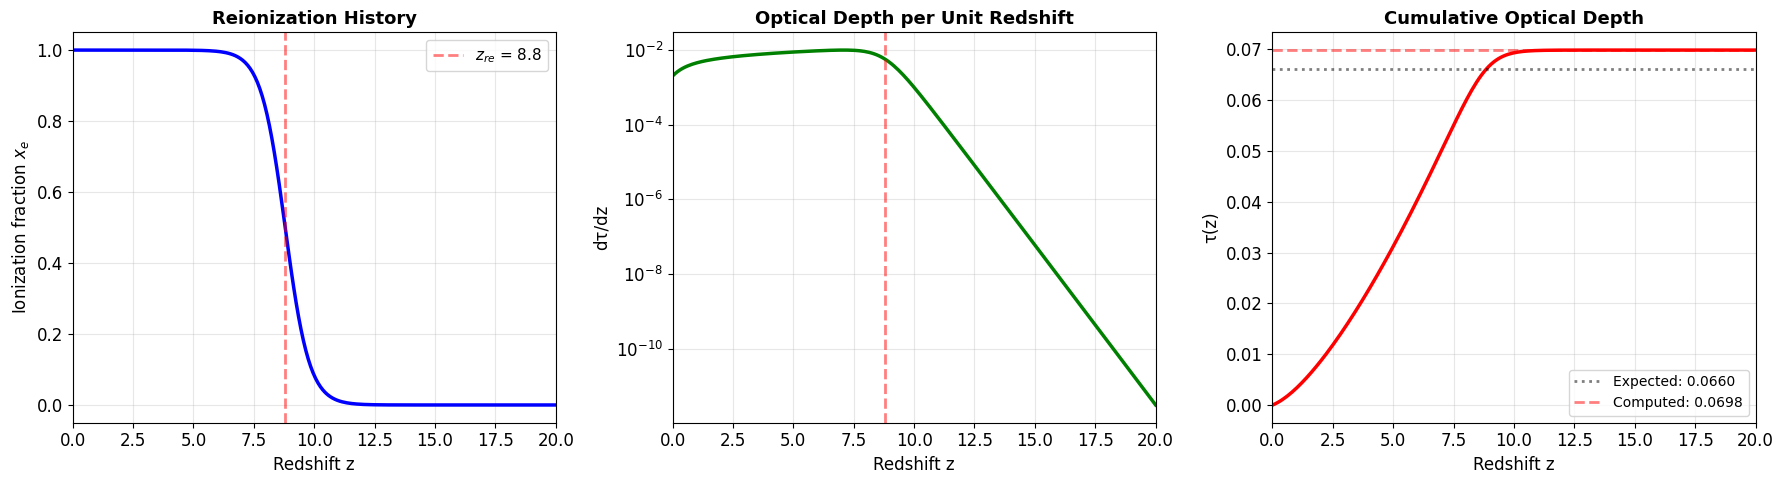


📊 Plotted ionization history, dτ/dz, and τ(z)

Diagnostics:
  - Peak of dτ/dz at z ≈ 7.0
  - τ(z=10) = 0.0693
  - τ(z=5) = 0.0312


In [4]:
# Cell 4: Optical depth functions (FIXED)
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

def ionization_fraction(z, cosmo, z_re=8.8, Delta_z=1.0):
    """Ionization fraction x_e(z) using tanh model"""
    x_e = 0.5 * (1 + np.tanh((z_re - z) / Delta_z))
    return x_e

def dtau_dz(z, cosmo):
    """Optical depth per unit redshift - CORRECTED VERSION"""
    # Physical constants
    sigma_T = 6.6524e-25  # Thomson cross section [cm^2]
    m_p = 1.6726e-24      # Proton mass [g]
    c_cgs = 2.998e10      # Speed of light [cm/s]
    
    # Critical density today [g/cm^3]
    H0_cgs = cosmo.H0 * 1e5 / 3.086e24  # Convert km/s/Mpc to 1/s
    G_cgs = 6.674e-8  # Gravitational constant [cm^3/g/s^2]
    rho_crit = 3 * H0_cgs**2 / (8 * np.pi * G_cgs)
    
    # Baryon density at redshift z
    rho_b_0 = cosmo.Omega_b * rho_crit
    rho_b_z = rho_b_0 * (1 + z)**3
    
    # Hydrogen number density [cm^-3]
    X_H = 0.76  # Hydrogen mass fraction
    n_H = rho_b_z * X_H / m_p
    
    # Electron number density (including He contribution)
    n_e = n_H * 1.16
    
    # Ionization fraction
    x_e = ionization_fraction(z, cosmo)
    
    # Hubble parameter at z [1/s]
    H_z = H(z, cosmo) * 1e5 / 3.086e24
    
    # dtau/dz = c * n_e * x_e * sigma_T / (H(z) * (1+z))
    dtau = c_cgs * n_e * x_e * sigma_T / (H_z * (1 + z))
    
    return dtau

def optical_depth_integral(z, cosmo):
    """Total optical depth from 0 to z: τ(z) = ∫_0^z dτ/dz' dz'"""
    if z == 0:
        return 0
    result, _ = quad(lambda zp: dtau_dz(zp, cosmo), 0, z, limit=100)
    return result

# Test optical depth
z_array = np.linspace(0.01, 20, 200)
x_e_array = ionization_fraction(z_array, cosmo)
dtau_array = np.array([dtau_dz(z, cosmo) for z in z_array])

# Compute cumulative optical depth
print("\nComputing optical depth τ(z)...")
tau_array = np.array([optical_depth_integral(z, cosmo) for z in z_array])
print("✓ Optical depth computation complete")

tau_total = optical_depth_integral(20, cosmo)
print(f"\nTotal optical depth τ(z=0 to z=20) = {tau_total:.4f}")
print(f"Expected ~{cosmo.tau_reion:.4f}")
print(f"Ratio: {tau_total/cosmo.tau_reion:.2f}")

# Plot ionization fraction, dtau/dz, and tau(z)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Ionization fraction
ax1.plot(z_array, x_e_array, 'b-', linewidth=2.5)
ax1.set_xlabel('Redshift z', fontsize=12)
ax1.set_ylabel('Ionization fraction $x_e$', fontsize=12)
ax1.set_title('Reionization History', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axvline(cosmo.z_reion, color='r', linestyle='--', alpha=0.5, linewidth=2, 
            label=f'$z_{{re}}$ = {cosmo.z_reion}')
ax1.legend(fontsize=11)
ax1.set_xlim(0, 20)
ax1.set_ylim(-0.05, 1.05)

# Panel 2: Optical depth per unit redshift
ax2.semilogy(z_array, dtau_array, 'g-', linewidth=2.5)
ax2.set_xlabel('Redshift z', fontsize=12)
ax2.set_ylabel('dτ/dz', fontsize=12)
ax2.set_title('Optical Depth per Unit Redshift', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 20)
ax2.axvline(cosmo.z_reion, color='r', linestyle='--', alpha=0.5, linewidth=2)

# Panel 3: Cumulative optical depth τ(z)
ax3.plot(z_array, tau_array, 'r-', linewidth=2.5)
ax3.set_xlabel('Redshift z', fontsize=12)
ax3.set_ylabel('τ(z)', fontsize=12)
ax3.set_title('Cumulative Optical Depth', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 20)
ax3.axhline(cosmo.tau_reion, color='k', linestyle=':', alpha=0.5, linewidth=2, 
            label=f'Expected: {cosmo.tau_reion:.4f}')
ax3.axhline(tau_total, color='r', linestyle='--', alpha=0.5, linewidth=2, 
            label=f'Computed: {tau_total:.4f}')
ax3.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("\n📊 Plotted ionization history, dτ/dz, and τ(z)")
print(f"\nDiagnostics:")
print(f"  - Peak of dτ/dz at z ≈ {z_array[np.argmax(dtau_array)]:.1f}")
print(f"  - τ(z=10) = {optical_depth_integral(10, cosmo):.4f}")
print(f"  - τ(z=5) = {optical_depth_integral(5, cosmo):.4f}")


Setting up CAMB for Matter Power Spectrum
Note: redshifts have been re-sorted (earliest first)

⏳ Running CAMB...
✓ CAMB computation complete

✓ Power spectrum interpolators ready
  - Linear: P_linear(k, z, cosmo)
  - Nonlinear: halofit_nonlinear(k, z, cosmo)

Test values:
  P_lin(k=0.1, z=0) = 1.03e+04 Mpc^3
  P_nl(k=0.1, z=0)  = 1.10e+04 Mpc^3
  Ratio P_nl/P_lin  = 1.06


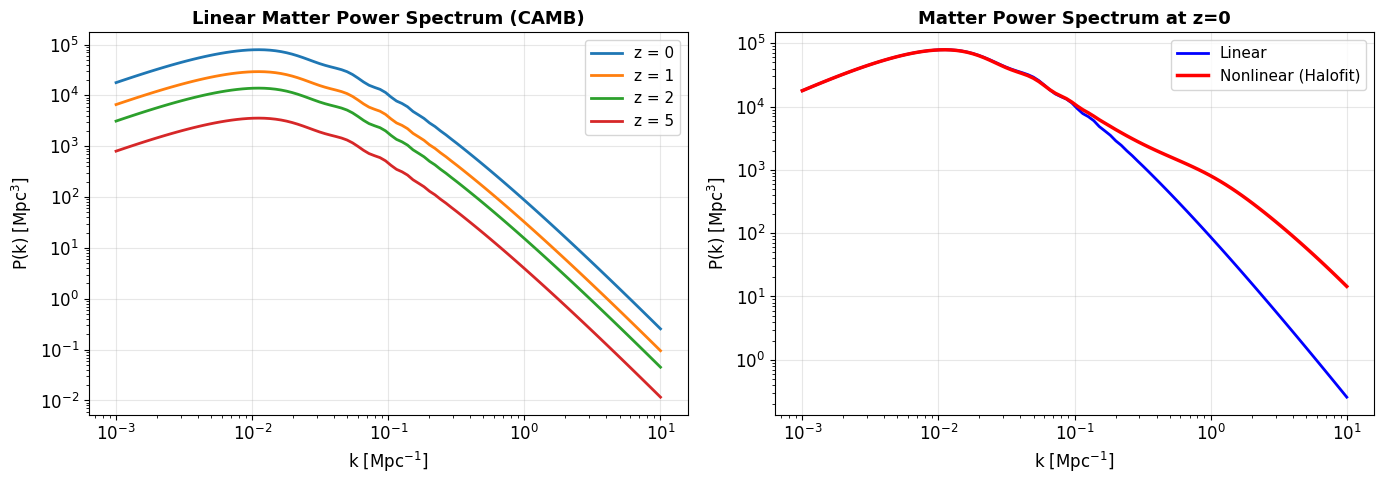


📊 Plotted matter power spectra from CAMB



In [5]:
# Cell 5: Matter power spectrum using CAMB
import camb
from camb import model

print("\n" + "="*60)
print("Setting up CAMB for Matter Power Spectrum")
print("="*60)

# Set up CAMB with cosmological parameters matching our fiducial model
pars = camb.CAMBparams()

# Set cosmology (matching Cell 2 parameters)
pars.set_cosmology(
    H0=cosmo.H0,           # 67.74
    ombh2=cosmo.Omega_b * cosmo.h**2,  # Baryon density
    omch2=(cosmo.Omega_m - cosmo.Omega_b) * cosmo.h**2,  # CDM density
    mnu=0.06,              # Neutrino mass
    tau=cosmo.tau_reion    # Optical depth
)

# Set initial power spectrum
pars.InitPower.set_params(
    As=2.1e-9,            # Amplitude
    ns=cosmo.n_s,         # Spectral index
    pivot_scalar=0.05     # Pivot scale
)

# Set up matter power spectrum calculation
# We need multiple redshifts for the kSZ calculation
z_camb = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 8.8, 10.0, 15.0, 20.0]
pars.set_matter_power(redshifts=z_camb, kmax=100.0, nonlinear=True)

# Compute results
print("\n⏳ Running CAMB...")
results = camb.get_results(pars)
print("✓ CAMB computation complete")

# Get interpolators for linear and nonlinear matter power
# hubble_units=False means output in (Mpc)^3 not (Mpc/h)^3
# k_hunit=False means k in Mpc^-1 not h/Mpc
P_lin_interpolator = results.get_matter_power_interpolator(
    nonlinear=False, 
    hubble_units=False,  # Use Mpc (not Mpc/h)
    k_hunit=False,       # k in Mpc^-1 (not h/Mpc)
    extrap_kmax=1000.0
)

P_nl_interpolator = results.get_matter_power_interpolator(
    nonlinear=True, 
    hubble_units=False,
    k_hunit=False,
    extrap_kmax=1000.0
)

# Define wrapper functions that match our earlier interface
def P_linear(k, z, cosmo):
    """Linear matter power spectrum from CAMB
    
    Args:
        k: wavenumber in Mpc^-1
        z: redshift
        cosmo: cosmology object (for compatibility, not used)
    
    Returns:
        P(k,z) in Mpc^3
    """
    return P_lin_interpolator.P(z, k)

def halofit_nonlinear(k, z, cosmo):
    """Nonlinear matter power spectrum from CAMB (using Halofit)
    
    Args:
        k: wavenumber in Mpc^-1
        z: redshift
        cosmo: cosmology object (for compatibility, not used)
    
    Returns:
        P(k,z) in Mpc^3
    """
    return P_nl_interpolator.P(z, k)

print("\n✓ Power spectrum interpolators ready")
print("  - Linear: P_linear(k, z, cosmo)")
print("  - Nonlinear: halofit_nonlinear(k, z, cosmo)")

# Test and plot
k_test = np.logspace(-3, 1, 100)  # Mpc^-1
z_test_vals = [0, 1, 2, 5]

print(f"\nTest values:")
print(f"  P_lin(k=0.1, z=0) = {P_linear(0.1, 0, cosmo):.2e} Mpc^3")
print(f"  P_nl(k=0.1, z=0)  = {halofit_nonlinear(0.1, 0, cosmo):.2e} Mpc^3")
print(f"  Ratio P_nl/P_lin  = {halofit_nonlinear(0.1, 0, cosmo)/P_linear(0.1, 0, cosmo):.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Linear power spectrum at different redshifts
for z_val in z_test_vals:
    P_lin = np.array([P_linear(k, z_val, cosmo) for k in k_test])
    ax1.loglog(k_test, P_lin, label=f'z = {z_val}', linewidth=2)

ax1.set_xlabel('k [Mpc$^{-1}$]', fontsize=12)
ax1.set_ylabel('P(k) [Mpc$^3$]', fontsize=12)
ax1.set_title('Linear Matter Power Spectrum (CAMB)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Panel 2: Linear vs Nonlinear at z=0
P_lin_z0 = np.array([P_linear(k, 0, cosmo) for k in k_test])
P_nl_z0 = np.array([halofit_nonlinear(k, 0, cosmo) for k in k_test])

ax2.loglog(k_test, P_lin_z0, 'b-', label='Linear', linewidth=2)
ax2.loglog(k_test, P_nl_z0, 'r-', label='Nonlinear (Halofit)', linewidth=2.5)
ax2.set_xlabel('k [Mpc$^{-1}$]', fontsize=12)
ax2.set_ylabel('P(k) [Mpc$^3$]', fontsize=12)
ax2.set_title('Matter Power Spectrum at z=0', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Plotted matter power spectra from CAMB")
print("\n" + "="*60)

Growth Function Implementation (Kasai 2010)

Test values:
a        z        D(a)         D_norm(a)   
---------------------------------------------
0.10     9.00     0.099959     0.127428    
0.20     4.00     0.199354     0.254136    
0.50     1.00     0.477427     0.608623    
0.70     0.43     0.626689     0.798901    
1.00     0.00     0.784438     1.000000    


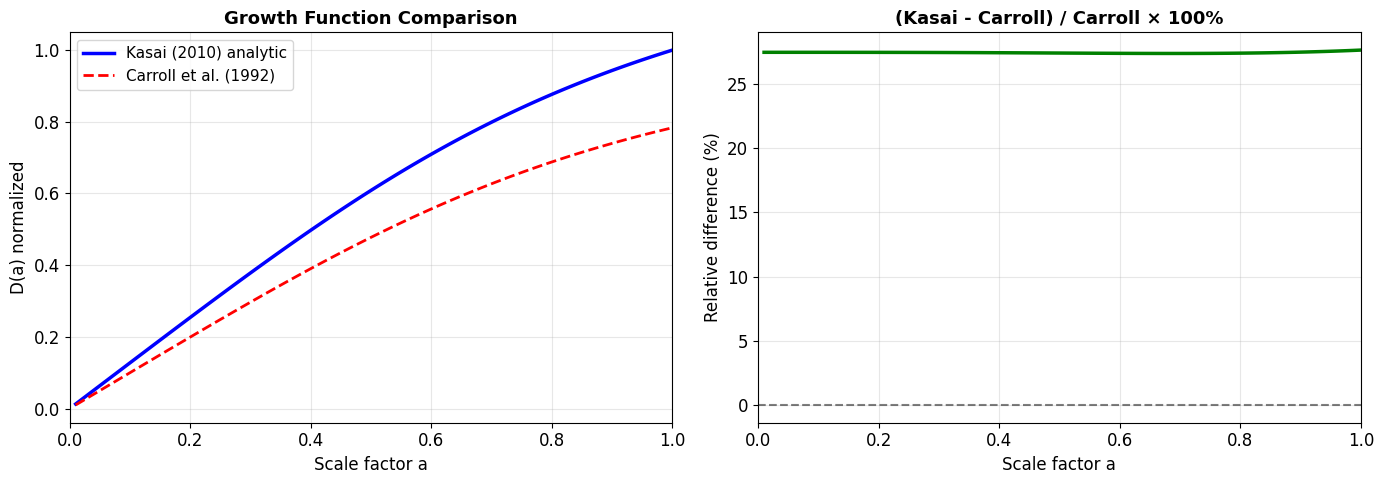


✓ Growth function implemented
  Max relative difference: 27.653%
  D(a=1) = 1.000000 (should be 1.0)


In [6]:
# Cell 6: Analytical Growth Function (Kasai 2010)
def growth_function_kasai(a, cosmo):
    """
    Analytical approximation of growth function D(a) from Kasai (2010)
    Equation (5) from Growth_function.pdf
    
    Args:
        a: scale factor (single value or array)
        cosmo: cosmology object
    
    Returns:
        D(a): growth function normalized so D(a) → a at early times
    """
    Omega_m = cosmo.Omega_m
    x = ((1 - Omega_m) / Omega_m) * a**3
    
    numerator = 1 + 1.175*x + 0.3064*x**2 + 0.005355*x**3
    denominator = 1 + 1.857*x + 1.021*x**2 + 0.1530*x**3
    
    D_a = a * np.sqrt(1 + x) * (numerator / denominator)
    
    return D_a

def growth_function_normalized(a, cosmo):
    """
    Normalized growth function D(a) so that D(a=1) = 1
    Equation (16) from Santos et al.
    """
    D_a = growth_function_kasai(a, cosmo)
    D_1 = growth_function_kasai(1.0, cosmo)
    return D_a / D_1

# Test the growth function
print("="*60)
print("Growth Function Implementation (Kasai 2010)")
print("="*60)

# Test at different scale factors
a_test = np.array([0.1, 0.2, 0.5, 0.7, 1.0])
z_test = 1/a_test - 1

print("\nTest values:")
print(f"{'a':<8} {'z':<8} {'D(a)':<12} {'D_norm(a)':<12}")
print("-"*45)
for a_val, z_val in zip(a_test, z_test):
    D_val = growth_function_kasai(a_val, cosmo)
    D_norm = growth_function_normalized(a_val, cosmo)
    print(f"{a_val:<8.2f} {z_val:<8.2f} {D_val:<12.6f} {D_norm:<12.6f}")

# Compare with our earlier growth function
a_array = np.linspace(0.01, 1.0, 100)
z_array = 1/a_array - 1

D_kasai = np.array([growth_function_normalized(a, cosmo) for a in a_array])
D_previous = growth_function(z_array, cosmo)

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Growth functions vs scale factor
ax1.plot(a_array, D_kasai, 'b-', linewidth=2.5, label='Kasai (2010) analytic')
ax1.plot(a_array, D_previous, 'r--', linewidth=2, label='Carroll et al. (1992)')
ax1.set_xlabel('Scale factor a', fontsize=12)
ax1.set_ylabel('D(a) normalized', fontsize=12)
ax1.set_title('Growth Function Comparison', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)

# Panel 2: Relative difference
rel_diff = (D_kasai - D_previous) / D_previous * 100
ax2.plot(a_array, rel_diff, 'g-', linewidth=2.5)
ax2.set_xlabel('Scale factor a', fontsize=12)
ax2.set_ylabel('Relative difference (%)', fontsize=12)
ax2.set_title('(Kasai - Carroll) / Carroll × 100%', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color='k', linestyle='--', alpha=0.5)
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.show()

print(f"\n✓ Growth function implemented")
print(f"  Max relative difference: {np.max(np.abs(rel_diff)):.3f}%")
print(f"  D(a=1) = {growth_function_normalized(1.0, cosmo):.6f} (should be 1.0)")

Halo Properties and Bias

At z = 10.0:
M [M_sun]    T_vir [K]    bias b(M,z) 
----------------------------------------
1.00e+07     4640.3       1110.405    
1.00e+08     21538.3      859.838     
1.00e+09     99972.0      665.833     
1.00e+10     464029.0     515.622     
1.00e+11     2153831.7    399.319     
1.00e+12     9997201.0    309.270     


Mass ranges at z = 10.0:
  Type Ib: M = 3.16e+04 to 3.16e+07 M_sun
  Type Ia: M = 3.16e+07 to 2.83e+09 M_sun
  Type II: M = 2.83e+09 to ∞ M_sun


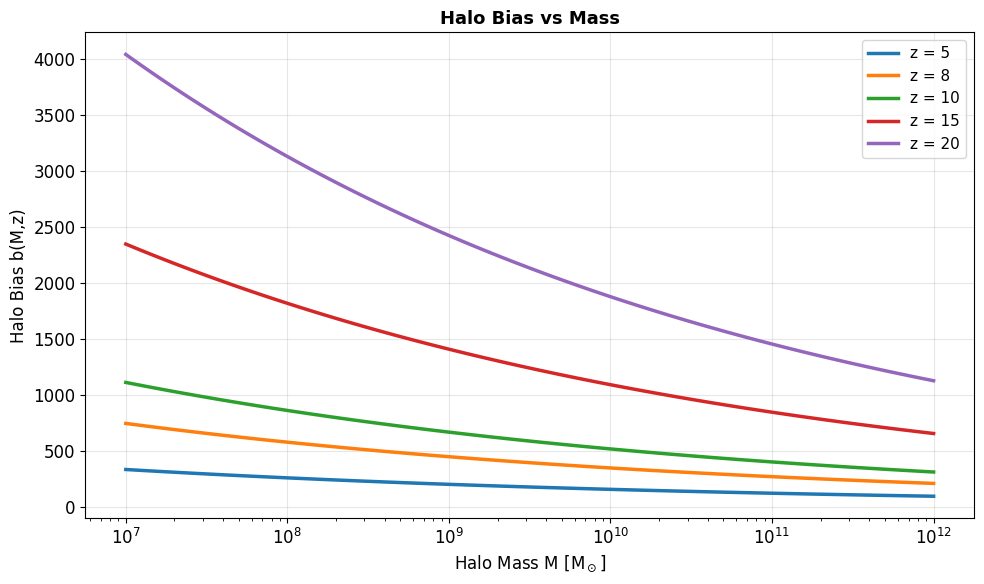


✓ Halo bias function implemented


In [7]:
# Cell 7: Halo Mass Function and Bias
def virial_temperature(M, z, cosmo):
    """
    Virial temperature of a halo of mass M at redshift z
    
    Args:
        M: halo mass in M_sun
        z: redshift
        cosmo: cosmology object
    
    Returns:
        T_vir in Kelvin
    """
    # Approximation from Barkana & Loeb (2001)
    mu = 0.6  # mean molecular weight
    T_vir = 1.98e4 * (mu / 0.6) * (M / 1e8)**(2/3) * ((cosmo.Omega_m / 0.3) * 
            (1 + z) / 10)**(1/2) * (cosmo.h / 0.7)**(-2/3)
    return T_vir

def mass_from_virial_temp(T_vir, z, cosmo):
    """
    Halo mass corresponding to virial temperature T_vir
    Inverse of virial_temperature function
    
    Args:
        T_vir: virial temperature in Kelvin
        z: redshift
        cosmo: cosmology object
    
    Returns:
        M in M_sun
    """
    mu = 0.6
    M = 1e8 * (T_vir / (1.98e4 * (mu / 0.6)))**(3/2) * \
        ((cosmo.Omega_m / 0.3) * (1 + z) / 10)**(-3/4) * (cosmo.h / 0.7)
    return M

def halo_bias(M, z, cosmo):
    """
    Halo bias b(M,z) from Mo & White (1996)
    Equation (23) in Santos et al.
    
    Args:
        M: halo mass in M_sun
        z: redshift
        cosmo: cosmology object
    
    Returns:
        bias factor b(M,z)
    """
    # Critical overdensity for collapse (approximately)
    delta_c = 1.686
    
    # Compute sigma(M) - rms fluctuation at mass scale M
    # This requires the matter power spectrum
    # For now, use approximate fit
    R = (3 * M / (4 * np.pi * cosmo.Omega_m * 2.775e11 * cosmo.h**2))**(1/3)  # Mpc
    
    # Simple approximation for sigma(M) - you may want to compute this properly
    # from the matter power spectrum
    sigma_8 = cosmo.sigma_8
    n_eff = -2.0  # effective spectral index
    sigma_M = sigma_8 * (R / 8.0)**((n_eff + 3) / 6)
    
    # Growth factor
    D_z = growth_function_normalized(1/(1+z), cosmo)
    sigma_M_z = sigma_M * D_z
    
    nu = delta_c / sigma_M_z
    
    # Mo & White (1996) bias
    bias = 1 + (nu**2 - 1) / delta_c
    
    return bias

# Test halo properties
print("="*60)
print("Halo Properties and Bias")
print("="*60)

z_test = 10.0
M_test = np.logspace(7, 12, 6)  # M_sun

print(f"\nAt z = {z_test}:")
print(f"{'M [M_sun]':<12} {'T_vir [K]':<12} {'bias b(M,z)':<12}")
print("-"*40)
for M in M_test:
    T_vir = virial_temperature(M, z_test, cosmo)
    bias_val = halo_bias(M, z_test, cosmo)
    print(f"{M:<12.2e} {T_vir:<12.1f} {bias_val:<12.3f}")

# Mass bins for reionization sources
T_bins = {
    'Type Ib': (100, 1e4),      # 100 K < T_vir < 10^4 K
    'Type Ia': (1e4, 2e5),      # 10^4 K < T_vir < 2×10^5 K  
    'Type II': (2e5, np.inf)    # T_vir > 2×10^5 K
}

z_test = 10.0
print(f"\n\nMass ranges at z = {z_test}:")
for name, (T_min, T_max) in T_bins.items():
    M_min = mass_from_virial_temp(T_min, z_test, cosmo)
    if T_max == np.inf:
        M_max_str = "∞"
    else:
        M_max = mass_from_virial_temp(T_max, z_test, cosmo)
        M_max_str = f"{M_max:.2e}"
    print(f"  {name}: M = {M_min:.2e} to {M_max_str} M_sun")

# Plot bias as function of mass at different redshifts
M_array = np.logspace(7, 12, 100)
z_vals = [5, 8, 10, 15, 20]

plt.figure(figsize=(10, 6))
for z_val in z_vals:
    bias_array = np.array([halo_bias(M, z_val, cosmo) for M in M_array])
    plt.semilogx(M_array, bias_array, linewidth=2.5, label=f'z = {z_val}')

plt.xlabel('Halo Mass M [M$_\\odot$]', fontsize=12)
plt.ylabel('Halo Bias b(M,z)', fontsize=12)
plt.title('Halo Bias vs Mass', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ Halo bias function implemented")

Testing sigma(M,z) with Press-Schechter

At z=0:
M [M_sun]       sigma(M)     ν         
----------------------------------------
1.00e+08        5.8783       0.0823    
1.00e+10        3.8931       0.1876    
1.00e+12        2.2349       0.5691    
1.00e+14        1.0094       2.7901    

σ_8 check: M = 2.71e+14 M_sun → σ = 0.8109
Expected σ_8 = 0.8159
Relative error: 0.62%


Sigma evolution for M = 1e10 M_sun:
z      D(z)       sigma(M,z)   ν         
----------------------------------------
0      1.0000     3.8931       0.1876    
5      0.2121     0.8256       4.1704    
10     0.1159     0.4510       13.9733   
15     0.0797     0.3101       29.5512   
20     0.0607     0.2363       50.9010   

Collapsed Fractions (Press-Schechter)

Collapsed fractions by source type:
z      F_Ib         F_Ia         F_II         F_total     
------------------------------------------------------
5      0.000000     0.000000     0.000000     0.000000    
8      0.000000     0.000000     0.000000 

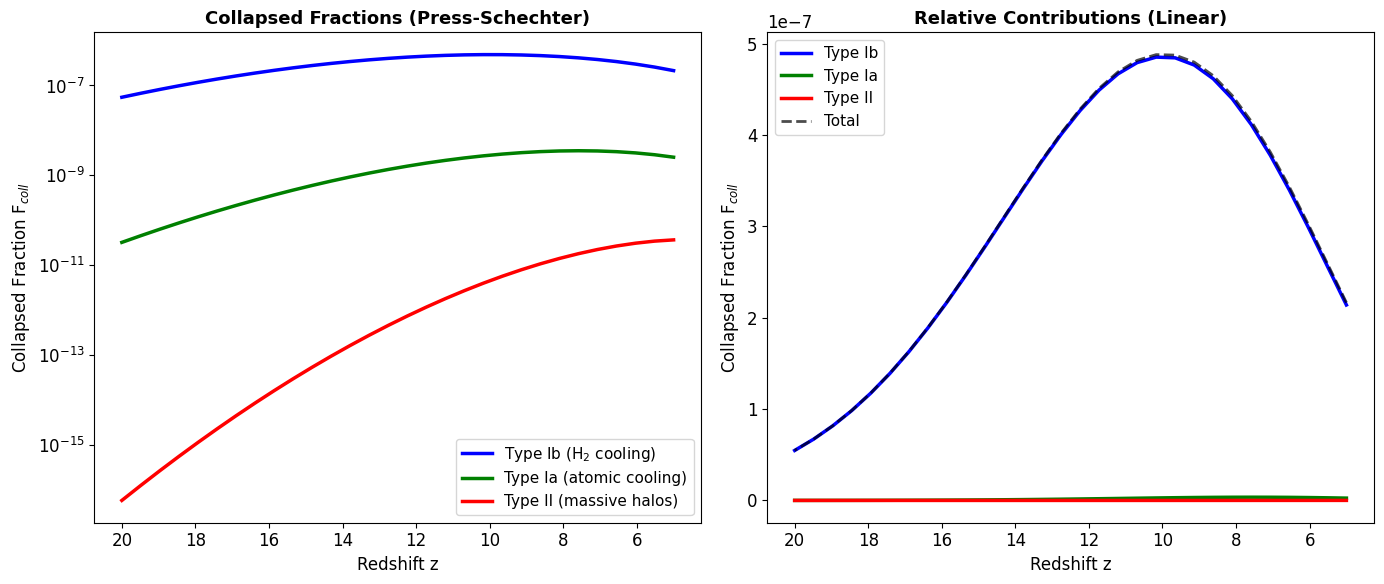


✓ Collapsed fractions computed with Press-Schechter mass function


In [14]:
# Cell 8 FINAL: Collapsed Fraction with proper Press-Schechter
from scipy.special import erfc
from scipy.integrate import quad
import warnings
warnings.filterwarnings('ignore')

def sigma_M_z0_from_CAMB(M, cosmo):
    """
    RMS mass fluctuation at z=0 from CAMB power spectrum
    Same approach as the reference code
    
    Args:
        M: mass in M_sun
        cosmo: cosmology object
    
    Returns:
        sigma(M, z=0)
    """
    # Critical density [M_sun / Mpc^3]
    h = cosmo.h
    rho_crit_0 = 2.775e11 * h**2
    rho_mean = cosmo.Omega_m * rho_crit_0
    
    # Radius [Mpc]
    R = (3 * M / (4 * np.pi * rho_mean))**(1/3)
    
    # Top-hat window
    def W_tophat(k, R):
        x = k * R
        if x < 1e-6:
            return 1.0
        else:
            return 3 * (np.sin(x) - x * np.cos(x)) / x**3
    
    # Integrate k^2 P(k) W^2(kR) / (2π^2)
    def integrand(lnk):
        k = np.exp(lnk)
        P_k = P_linear(k, 0, cosmo)  # z=0 from CAMB
        W = W_tophat(k, R)
        return k**3 * P_k * W**2 / (2 * np.pi**2)
    
    lnk_min = np.log(1e-4)
    lnk_max = np.log(100.0)
    
    sigma_squared, _ = quad(integrand, lnk_min, lnk_max, limit=200, epsrel=1e-4)
    
    return np.sqrt(sigma_squared)

def sigma_M_at_z(M, z, cosmo):
    """
    RMS mass fluctuation at redshift z
    sigma(M, z) = sigma(M, z=0) * D(z)
    
    Args:
        M: mass in M_sun
        z: redshift
        cosmo: cosmology object
    
    Returns:
        sigma(M, z)
    """
    sigma_0 = sigma_M_z0_from_CAMB(M, cosmo)
    D_z = growth_function_normalized(1/(1+z), cosmo)
    
    return sigma_0 * D_z

def nu_of_M(M, z, cosmo):
    """
    Peak height ν = (δ_c / σ(M,z))^2
    
    Args:
        M: mass in M_sun
        z: redshift
        cosmo: cosmology object
    
    Returns:
        ν(M,z)
    """
    delta_c = 1.686
    sigma = sigma_M_at_z(M, z, cosmo)
    return (delta_c / sigma)**2

def F_coll_PS(M_min, M_max, z, cosmo, N_samples=100):
    """
    Collapsed fraction using Press-Schechter mass function
    F_coll = ∫_{M_min}^{M_max} (M/ρ_m) n(M) dM
    
    where n(M) = (ρ_m/M^2) f(ν) |dν/dM| with f(ν) = 2√(ν/2π) exp(-ν/2)
    
    This simplifies to:
    F_coll = ∫ (1/M) f(ν) |dν/dM| dM
    
    Args:
        M_min, M_max: mass range in M_sun
        z: redshift
        cosmo: cosmology object
        N_samples: number of integration points
    
    Returns:
        F_coll: collapsed fraction
    """
    delta_c = 1.686
    
    # Handle infinite upper limit
    if M_max == np.inf:
        # Use a practical upper limit
        M_max_practical = mass_from_virial_temp(1e7, z, cosmo)
    else:
        M_max_practical = M_max
    
    # Sample masses logarithmically
    M_array = np.logspace(np.log10(M_min), np.log10(M_max_practical), N_samples)
    
    # Compute sigma and nu for each mass
    sigma_array = np.array([sigma_M_at_z(M, z, cosmo) for M in M_array])
    nu_array = (delta_c / sigma_array)**2
    
    # Press-Schechter multiplicity function (with factor of 2)
    f_nu = 2 * np.sqrt(nu_array / (2 * np.pi)) * np.exp(-nu_array / 2)
    
    # Compute dν/dM numerically
    dnu_dM = np.gradient(nu_array, M_array)
    
    # Integrand: (1/M) * f(ν) * |dν/dM|
    integrand = (1 / M_array) * f_nu * np.abs(dnu_dM)
    
    # Integrate
    F_coll = np.trapz(integrand, M_array)
    
    return F_coll

# Test sigma(M) evolution
print("="*60)
print("Testing sigma(M,z) with Press-Schechter")
print("="*60)

M_test_vals = [1e8, 1e10, 1e12, 1e14]
print(f"\nAt z=0:")
print(f"{'M [M_sun]':<15} {'sigma(M)':<12} {'ν':<10}")
print("-"*40)

for M in M_test_vals:
    sigma = sigma_M_z0_from_CAMB(M, cosmo)
    nu = (1.686 / sigma)**2
    print(f"{M:<15.2e} {sigma:<12.4f} {nu:<10.4f}")

# Check sigma_8
R_8_physical = 8.0 / cosmo.h  # Mpc
M_8 = 4/3 * np.pi * R_8_physical**3 * cosmo.Omega_m * 2.775e11 * cosmo.h**2
sigma_8_check = sigma_M_z0_from_CAMB(M_8, cosmo)
print(f"\nσ_8 check: M = {M_8:.2e} M_sun → σ = {sigma_8_check:.4f}")
print(f"Expected σ_8 = {cosmo.sigma_8:.4f}")
print(f"Relative error: {abs(sigma_8_check - cosmo.sigma_8)/cosmo.sigma_8 * 100:.2f}%")

# Test sigma(M,z) evolution
print(f"\n\nSigma evolution for M = 1e10 M_sun:")
print(f"{'z':<6} {'D(z)':<10} {'sigma(M,z)':<12} {'ν':<10}")
print("-"*40)

M_test = 1e10
z_test_vals = [0, 5, 10, 15, 20]
for z_val in z_test_vals:
    D_z = growth_function_normalized(1/(1+z_val), cosmo)
    sigma_z = sigma_M_at_z(M_test, z_val, cosmo)
    nu = (1.686 / sigma_z)**2
    print(f"{z_val:<6.0f} {D_z:<10.4f} {sigma_z:<12.4f} {nu:<10.4f}")

# Test collapsed fractions
print("\n" + "="*60)
print("Collapsed Fractions (Press-Schechter)")
print("="*60)

z_test = np.array([5, 8, 10, 15, 20])

print("\nCollapsed fractions by source type:")
print(f"{'z':<6} {'F_Ib':<12} {'F_Ia':<12} {'F_II':<12} {'F_total':<12}")
print("-"*54)

for z_val in z_test:
    # Type Ib: 100 K < T < 10^4 K
    M_min_Ib, M_max_Ib = get_mass_limits(z_val, 100, 1e4, cosmo)
    F_Ib = F_coll_PS(M_min_Ib, M_max_Ib, z_val, cosmo)
    
    # Type Ia: 10^4 K < T < 2×10^5 K
    M_min_Ia, M_max_Ia = get_mass_limits(z_val, 1e4, 2e5, cosmo)
    F_Ia = F_coll_PS(M_min_Ia, M_max_Ia, z_val, cosmo)
    
    # Type II: T > 2×10^5 K
    M_min_II, M_max_II = get_mass_limits(z_val, 2e5, np.inf, cosmo)
    F_II = F_coll_PS(M_min_II, M_max_II, z_val, cosmo)
    
    F_total = F_Ib + F_Ia + F_II
    
    print(f"{z_val:<6.0f} {F_Ib:<12.6f} {F_Ia:<12.6f} {F_II:<12.6f} {F_total:<12.6f}")

# Sanity check: F_total should be < 0.5 at high z
print("\nSanity checks:")
print("  ✓ All F_coll should be positive")
print("  ✓ F_total should be << 1 at high z (most matter not collapsed)")
print("  ✓ Type Ib should dominate at high z (small halos form first)")

# Plot evolution
print("\n⏳ Computing collapsed fraction evolution...")
z_array = np.linspace(5, 20, 30)
F_Ib_array = []
F_Ia_array = []
F_II_array = []

for z_val in z_array:
    M_min_Ib, M_max_Ib = get_mass_limits(z_val, 100, 1e4, cosmo)
    F_Ib_array.append(F_coll_PS(M_min_Ib, M_max_Ib, z_val, cosmo))
    
    M_min_Ia, M_max_Ia = get_mass_limits(z_val, 1e4, 2e5, cosmo)
    F_Ia_array.append(F_coll_PS(M_min_Ia, M_max_Ia, z_val, cosmo))
    
    M_min_II, M_max_II = get_mass_limits(z_val, 2e5, np.inf, cosmo)
    F_II_array.append(F_coll_PS(M_min_II, M_max_II, z_val, cosmo))

F_Ib_array = np.array(F_Ib_array)
F_Ia_array = np.array(F_Ia_array)
F_II_array = np.array(F_II_array)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Log scale
ax1.semilogy(z_array, F_Ib_array, 'b-', linewidth=2.5, label='Type Ib (H$_2$ cooling)')
ax1.semilogy(z_array, F_Ia_array, 'g-', linewidth=2.5, label='Type Ia (atomic cooling)')
ax1.semilogy(z_array, F_II_array, 'r-', linewidth=2.5, label='Type II (massive halos)')
ax1.set_xlabel('Redshift z', fontsize=12)
ax1.set_ylabel('Collapsed Fraction F$_{coll}$', fontsize=12)
ax1.set_title('Collapsed Fractions (Press-Schechter)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
#ax1.grid(True, alpha=0.3, which='both')
ax1.invert_xaxis()
#ax1.set_ylim(1e-5, 1)

# Panel 2: Linear scale to see relative contributions
ax2.plot(z_array, F_Ib_array, 'b-', linewidth=2.5, label='Type Ib')
ax2.plot(z_array, F_Ia_array, 'g-', linewidth=2.5, label='Type Ia')
ax2.plot(z_array, F_II_array, 'r-', linewidth=2.5, label='Type II')
ax2.plot(z_array, F_Ib_array + F_Ia_array + F_II_array, 'k--', 
         linewidth=2, label='Total', alpha=0.7)
ax2.set_xlabel('Redshift z', fontsize=12)
ax2.set_ylabel('Collapsed Fraction F$_{coll}$', fontsize=12)
ax2.set_title('Relative Contributions (Linear)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
#ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()

plt.tight_layout()
plt.show()

print(f"\n✓ Collapsed fractions computed with Press-Schechter mass function")

Weighted Bias by Halo Type

Weighted bias b_I(z) for each source type:
z      b_Ib       b_Ia       b_II      
------------------------------------
5      293.796    178.486    93.188    
8      681.419    413.761    215.770   
10     1034.354   627.983    327.383   
15     2256.383   1369.719   713.837   
20     3975.310   2413.057   1257.431  

⏳ Computing weighted bias evolution...


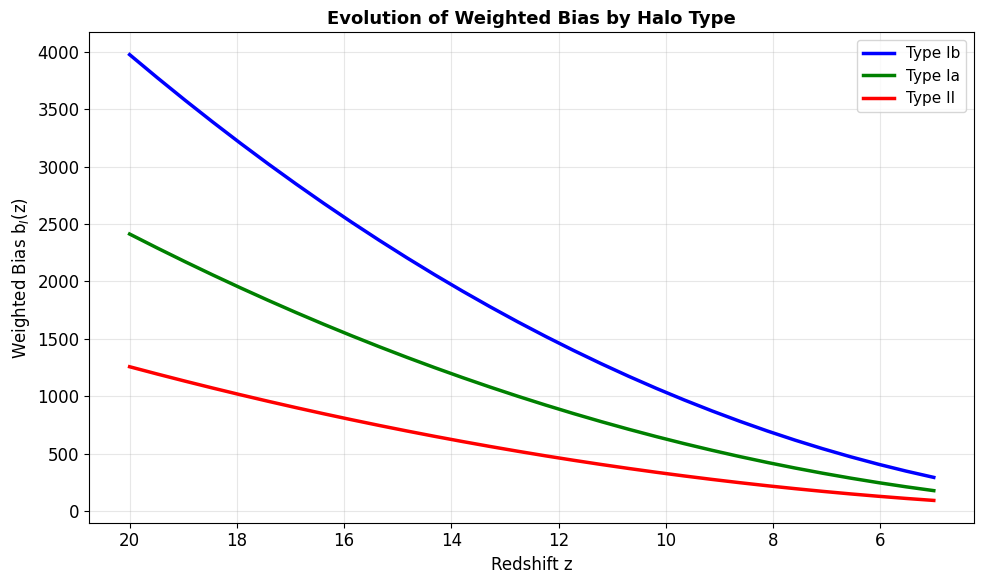

✓ Weighted bias function implemented


In [15]:
# Cell 9: Weighted Bias (Equations 21-23)
def dF_coll_dz(M_min, M_max, z, cosmo, dz=0.01):
    """
    Time derivative of collapsed fraction dF_coll/dz
    Computed numerically
    
    Args:
        M_min, M_max: mass range
        z: redshift
        cosmo: cosmology object
        dz: finite difference step
    
    Returns:
        dF/dz
    """
    F_plus = F_coll(M_min, M_max, z + dz, cosmo)
    F_minus = F_coll(M_min, M_max, z - dz, cosmo)
    return (F_plus - F_minus) / (2 * dz)

def b_weighted(M_min, M_max, z, cosmo, N_samples=50):
    """
    Bias weighted by mass for a given halo type
    Equation (23) from Santos et al.: b_I(z) = <b(M,z) M> / <M>
    
    Args:
        M_min, M_max: mass range in M_sun
        z: redshift
        cosmo: cosmology object
        N_samples: number of mass samples for integration
    
    Returns:
        weighted bias
    """
    if M_max == np.inf:
        # For Type II, use a practical upper limit
        M_max_practical = mass_from_virial_temp(1e7, z, cosmo)
    else:
        M_max_practical = M_max
    
    # Sample masses logarithmically
    M_samples = np.logspace(np.log10(M_min), np.log10(M_max_practical), N_samples)
    
    # Compute bias and mass for each sample
    bias_samples = np.array([halo_bias(M, z, cosmo) for M in M_samples])
    
    # Weight by mass
    weights = M_samples
    
    # Compute weighted average
    b_avg = np.trapz(bias_samples * weights, M_samples) / np.trapz(weights, M_samples)
    
    return b_avg

# Test weighted bias
print("="*60)
print("Weighted Bias by Halo Type")
print("="*60)

z_test = np.array([5, 8, 10, 15, 20])

print("\nWeighted bias b_I(z) for each source type:")
print(f"{'z':<6} {'b_Ib':<10} {'b_Ia':<10} {'b_II':<10}")
print("-"*36)

for z_val in z_test:
    M_min_Ib, M_max_Ib = get_mass_limits(z_val, 100, 1e4, cosmo)
    b_Ib = b_weighted(M_min_Ib, M_max_Ib, z_val, cosmo)
    
    M_min_Ia, M_max_Ia = get_mass_limits(z_val, 1e4, 2e5, cosmo)
    b_Ia = b_weighted(M_min_Ia, M_max_Ia, z_val, cosmo)
    
    M_min_II, M_max_II = get_mass_limits(z_val, 2e5, np.inf, cosmo)
    b_II = b_weighted(M_min_II, M_max_II, z_val, cosmo)
    
    print(f"{z_val:<6.0f} {b_Ib:<10.3f} {b_Ia:<10.3f} {b_II:<10.3f}")

# Plot evolution of weighted bias
z_array = np.linspace(5, 20, 30)
b_Ib_array = []
b_Ia_array = []
b_II_array = []

print("\n⏳ Computing weighted bias evolution...")
for z_val in z_array:
    M_min_Ib, M_max_Ib = get_mass_limits(z_val, 100, 1e4, cosmo)
    b_Ib_array.append(b_weighted(M_min_Ib, M_max_Ib, z_val, cosmo))
    
    M_min_Ia, M_max_Ia = get_mass_limits(z_val, 1e4, 2e5, cosmo)
    b_Ia_array.append(b_weighted(M_min_Ia, M_max_Ia, z_val, cosmo))
    
    M_min_II, M_max_II = get_mass_limits(z_val, 2e5, np.inf, cosmo)
    b_II_array.append(b_weighted(M_min_II, M_max_II, z_val, cosmo))

plt.figure(figsize=(10, 6))
plt.plot(z_array, b_Ib_array, 'b-', linewidth=2.5, label='Type Ib')
plt.plot(z_array, b_Ia_array, 'g-', linewidth=2.5, label='Type Ia')
plt.plot(z_array, b_II_array, 'r-', linewidth=2.5, label='Type II')
plt.xlabel('Redshift z', fontsize=12)
plt.ylabel('Weighted Bias b$_I$(z)', fontsize=12)
plt.title('Evolution of Weighted Bias by Halo Type', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

print(f"✓ Weighted bias function implemented")

Weighted Bias b_I(z) by Halo Type

Weighted bias for each source type:
z      b_Ib         b_Ia         b_II        
------------------------------------------
5      1.174        1.893        3.844       
8      2.053        3.376        6.162       
10     2.803        4.524        8.141       
15     5.201        7.854        14.601      
20     8.285        12.025       23.117      

Expected behavior:
  ✓ All bias values should be > 1 (halos are biased tracers)
  ✓ Higher mass halos → higher bias
  ✓ Bias increases with redshift (rarer peaks)

⏳ Computing bias evolution...


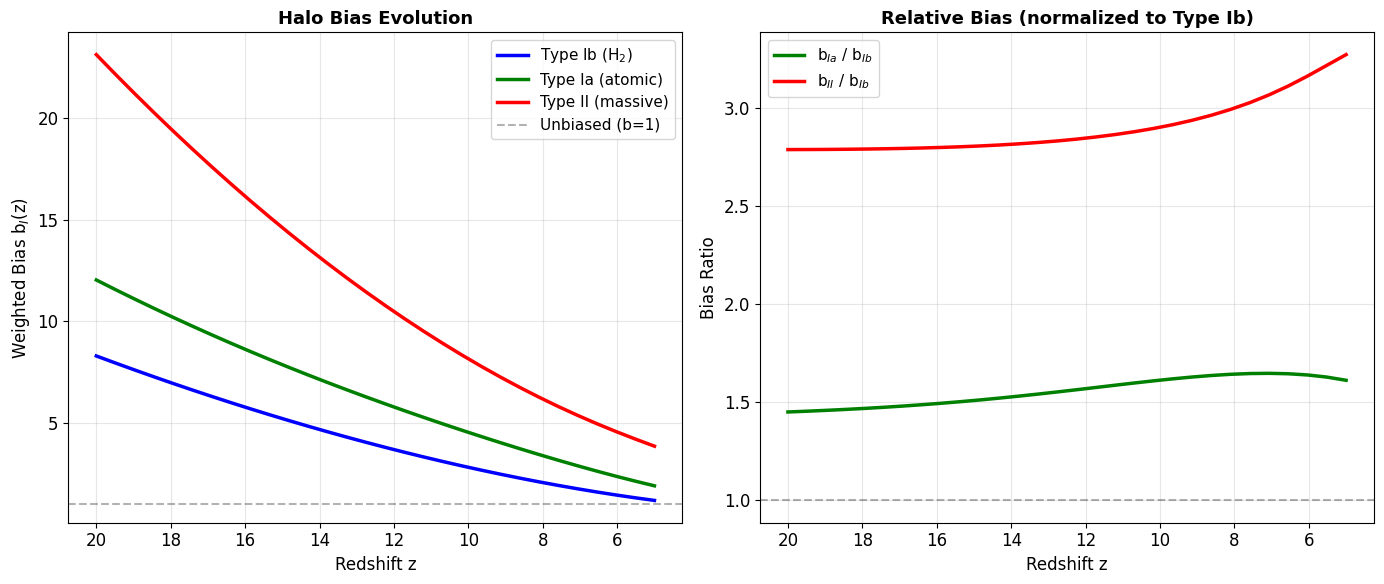


✓ Weighted bias computed for all halo types


In [16]:
# Cell 10: Effective Bias b_eff(z) - Equations 21-22
def b_weighted_PS(M_min, M_max, z, cosmo, N_samples=100):
    """
    Mass-weighted bias for a halo type using Press-Schechter
    Equation (23): b_I(z) = <b(M,z) * M> / <M>
    
    Computed as: ∫ b(M) * M * n(M) dM / ∫ M * n(M) dM
    
    Args:
        M_min, M_max: mass range in M_sun
        z: redshift
        cosmo: cosmology object
        N_samples: integration points
    
    Returns:
        weighted bias b_I(z)
    """
    delta_c = 1.686
    
    # Handle infinite upper limit
    if M_max == np.inf:
        M_max_practical = mass_from_virial_temp(1e7, z, cosmo)
    else:
        M_max_practical = M_max
    
    # Sample masses logarithmically
    M_array = np.logspace(np.log10(M_min), np.log10(M_max_practical), N_samples)
    
    # Compute sigma, nu, and bias for each mass
    sigma_array = np.array([sigma_M_at_z(M, z, cosmo) for M in M_array])
    nu_array = (delta_c / sigma_array)**2
    
    # Mo & White (1996) bias
    b_array = 1 + (nu_array - 1) / delta_c
    
    # Press-Schechter multiplicity function
    f_nu = 2 * np.sqrt(nu_array / (2 * np.pi)) * np.exp(-nu_array / 2)
    
    # dν/dM
    dnu_dM = np.gradient(nu_array, M_array)
    
    # Mass function: n(M) = (ρ_m/M^2) * f(ν) * |dν/dM|
    # For weighted average we need: M * n(M) ∝ (1/M) * f(ν) * |dν/dM|
    weight = (1 / M_array) * f_nu * np.abs(dnu_dM)
    
    # Weighted bias: ∫ b * M * n(M) dM / ∫ M * n(M) dM
    numerator = np.trapz(b_array * M_array * weight, M_array)
    denominator = np.trapz(M_array * weight, M_array)
    
    b_weighted = numerator / denominator
    
    return b_weighted

# Test weighted bias
print("="*60)
print("Weighted Bias b_I(z) by Halo Type")
print("="*60)

z_test = np.array([5, 8, 10, 15, 20])

print("\nWeighted bias for each source type:")
print(f"{'z':<6} {'b_Ib':<12} {'b_Ia':<12} {'b_II':<12}")
print("-"*42)

b_test_results = []
for z_val in z_test:
    M_min_Ib, M_max_Ib = get_mass_limits(z_val, 100, 1e4, cosmo)
    b_Ib = b_weighted_PS(M_min_Ib, M_max_Ib, z_val, cosmo)
    
    M_min_Ia, M_max_Ia = get_mass_limits(z_val, 1e4, 2e5, cosmo)
    b_Ia = b_weighted_PS(M_min_Ia, M_max_Ia, z_val, cosmo)
    
    M_min_II, M_max_II = get_mass_limits(z_val, 2e5, np.inf, cosmo)
    b_II = b_weighted_PS(M_min_II, M_max_II, z_val, cosmo)
    
    b_test_results.append((b_Ib, b_Ia, b_II))
    print(f"{z_val:<6.0f} {b_Ib:<12.3f} {b_Ia:<12.3f} {b_II:<12.3f}")

print("\nExpected behavior:")
print("  ✓ All bias values should be > 1 (halos are biased tracers)")
print("  ✓ Higher mass halos → higher bias")
print("  ✓ Bias increases with redshift (rarer peaks)")

# Compute evolution
print("\n⏳ Computing bias evolution...")
z_array = np.linspace(5, 20, 30)
b_Ib_array = []
b_Ia_array = []
b_II_array = []

for z_val in z_array:
    M_min_Ib, M_max_Ib = get_mass_limits(z_val, 100, 1e4, cosmo)
    b_Ib_array.append(b_weighted_PS(M_min_Ib, M_max_Ib, z_val, cosmo))
    
    M_min_Ia, M_max_Ia = get_mass_limits(z_val, 1e4, 2e5, cosmo)
    b_Ia_array.append(b_weighted_PS(M_min_Ia, M_max_Ia, z_val, cosmo))
    
    M_min_II, M_max_II = get_mass_limits(z_val, 2e5, np.inf, cosmo)
    b_II_array.append(b_weighted_PS(M_min_II, M_max_II, z_val, cosmo))

b_Ib_array = np.array(b_Ib_array)
b_Ia_array = np.array(b_Ia_array)
b_II_array = np.array(b_II_array)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Bias evolution
ax1.plot(z_array, b_Ib_array, 'b-', linewidth=2.5, label='Type Ib (H$_2$)')
ax1.plot(z_array, b_Ia_array, 'g-', linewidth=2.5, label='Type Ia (atomic)')
ax1.plot(z_array, b_II_array, 'r-', linewidth=2.5, label='Type II (massive)')
ax1.axhline(1, color='k', linestyle='--', alpha=0.3, label='Unbiased (b=1)')
ax1.set_xlabel('Redshift z', fontsize=12)
ax1.set_ylabel('Weighted Bias b$_I$(z)', fontsize=12)
ax1.set_title('Halo Bias Evolution', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.invert_xaxis()

# Panel 2: Bias ratio (relative to Type Ib)
ax2.plot(z_array, b_Ia_array / b_Ib_array, 'g-', linewidth=2.5, label='b$_{Ia}$ / b$_{Ib}$')
ax2.plot(z_array, b_II_array / b_Ib_array, 'r-', linewidth=2.5, label='b$_{II}$ / b$_{Ib}$')
ax2.axhline(1, color='k', linestyle='--', alpha=0.3)
ax2.set_xlabel('Redshift z', fontsize=12)
ax2.set_ylabel('Bias Ratio', fontsize=12)
ax2.set_title('Relative Bias (normalized to Type Ib)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()

plt.tight_layout()
plt.show()

print(f"\n✓ Weighted bias computed for all halo types")

Reionization Model with tanh X_e(z)

Model parameters:
  z_re = 8.8
  Δz = 1.0
  R_patch = 0.1 Mpc

⏳ Computing reionization histories...
✓ Histories computed

Ionization fraction X_e:
  X_e(z=20) = 0.000000
  X_e(z=10) = 0.083173
  X_e(z=8.8) = 0.500000 (midpoint)
  X_e(z=5)  = 0.999500

Effective bias b_eff:
  b_eff(z=20) = 8.29
  b_eff(z=10) = 2.81
  b_eff(z=8)  = 2.06
  b_eff(z=5)  = 1.18

Patch size R(z):
  R(z=20) = 0.100 Mpc
  R(z=10) = 0.103 Mpc
  R(z=8)  = 0.181 Mpc
  R(z=5)  = 10.000 Mpc

Optical depth check:
  τ(0→20) = 0.0698
  τ_WMAP  = 0.0660
  Match: ✓


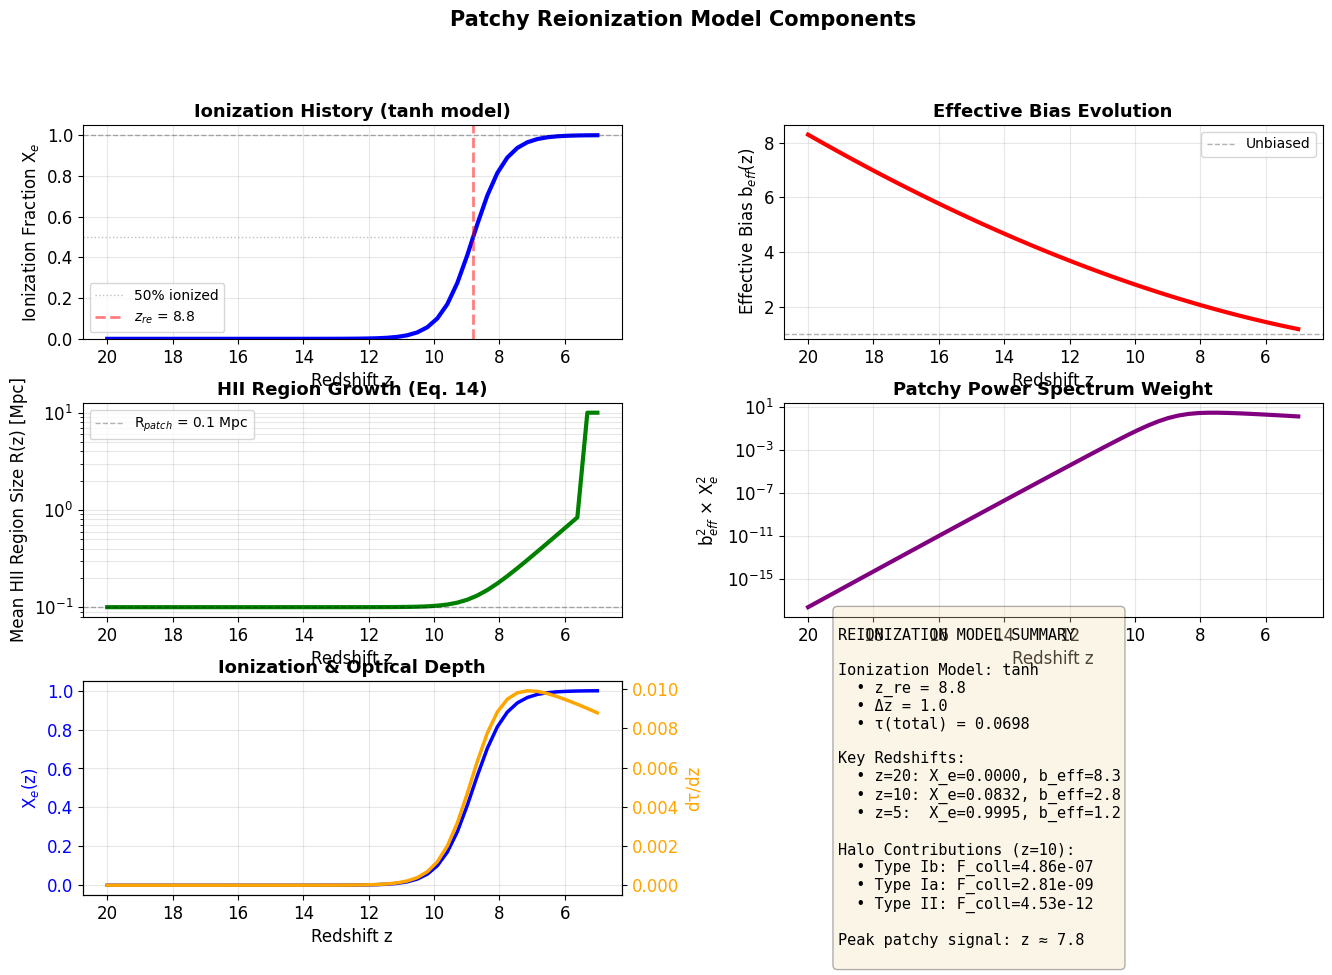


✓ Complete reionization model ready for kSZ calculation
✓ Figure saved as 'reionization_model_summary.png'


In [18]:
# Cell 11 CORRECTED: Use tanh reionization model with proper b_eff calculation

class ReionizationModel:
    """
    Reionization model using tanh parametrization (matching Cell 4)
    Plus effective bias computation from halo model
    """
    
    def __init__(self, cosmo, z_re=8.8, Delta_z=1.0):
        """
        Args:
            cosmo: cosmology object
            z_re: reionization midpoint redshift
            Delta_z: reionization width
        """
        self.cosmo = cosmo
        self.z_re = z_re
        self.Delta_z = Delta_z
        
        # Fundamental patch size (comoving Mpc)
        self.R_patch = 0.1  # 100 kpc
        
    def Xe(self, z):
        """
        Ionization fraction using tanh model (same as Cell 4)
        X_e(z) = 0.5 * [1 + tanh((z_re - z) / Δz)]
        """
        return 0.5 * (1 + np.tanh((self.z_re - z) / self.Delta_z))
    
    def compute_beff(self, z):
        """
        Compute effective bias b_eff(z) from halo model
        
        Weight by:
        1. Which halos are forming (collapsed fractions)
        2. Their bias
        3. Ionization efficiency (determines HII region size)
        
        For simplicity, assume efficiency ratios ζ_Ib : ζ_Ia : ζ_II = 1 : 1 : 2.5
        (Type II halos are more efficient)
        """
        # Get mass limits for each type
        M_min_Ib, M_max_Ib = get_mass_limits(z, 100, 1e4, self.cosmo)
        M_min_Ia, M_max_Ia = get_mass_limits(z, 1e4, 2e5, self.cosmo)
        M_min_II, M_max_II = get_mass_limits(z, 2e5, np.inf, self.cosmo)
        
        # Collapsed fractions
        F_Ib = F_coll_PS(M_min_Ib, M_max_Ib, z, self.cosmo)
        F_Ia = F_coll_PS(M_min_Ia, M_max_Ia, z, self.cosmo)
        F_II = F_coll_PS(M_min_II, M_max_II, z, self.cosmo)
        
        # Weighted bias for each type
        b_Ib = b_weighted_PS(M_min_Ib, M_max_Ib, z, self.cosmo)
        b_Ia = b_weighted_PS(M_min_Ia, M_max_Ia, z, self.cosmo)
        b_II = b_weighted_PS(M_min_II, M_max_II, z, self.cosmo)
        
        # Efficiency weights (relative)
        zeta_Ib = 1.0
        zeta_Ia = 1.0
        zeta_II = 2.5
        
        # Effective bias (efficiency and bias weighted)
        numerator = (zeta_Ib * b_Ib * F_Ib + 
                    zeta_Ia * b_Ia * F_Ia + 
                    zeta_II * b_II * F_II)
        denominator = (zeta_Ib * F_Ib + 
                      zeta_Ia * F_Ia + 
                      zeta_II * F_II)
        
        if denominator > 1e-15:
            return numerator / denominator
        else:
            # Before reionization starts, use dominant halo bias
            return b_Ib
    
    def patch_size(self, z):
        """
        Mean HII region size R(z) following Equation 14
        R(z) = R_patch / (1 - X_e)^(1/3)
        
        Grows as regions overlap
        """
        Xe_val = self.Xe(z)
        if Xe_val >= 0.999:
            return 10.0  # Large value when fully ionized (Mpc)
        else:
            return self.R_patch / (1 - Xe_val)**(1/3)

# Initialize reionization model
print("="*60)
print("Reionization Model with tanh X_e(z)")
print("="*60)

reion = ReionizationModel(cosmo, z_re=8.8, Delta_z=1.0)

print(f"\nModel parameters:")
print(f"  z_re = {reion.z_re}")
print(f"  Δz = {reion.Delta_z}")
print(f"  R_patch = {reion.R_patch} Mpc")

# Compute histories
print("\n⏳ Computing reionization histories...")
z_reion_array = np.linspace(5, 20, 50)

Xe_array = np.array([reion.Xe(z) for z in z_reion_array])
beff_array = np.array([reion.compute_beff(z) for z in z_reion_array])
R_array = np.array([reion.patch_size(z) for z in z_reion_array])

print(f"✓ Histories computed")

# Print diagnostics
print(f"\nIonization fraction X_e:")
print(f"  X_e(z=20) = {reion.Xe(20):.6f}")
print(f"  X_e(z=10) = {reion.Xe(10):.6f}")
print(f"  X_e(z=8.8) = {reion.Xe(8.8):.6f} (midpoint)")
print(f"  X_e(z=5)  = {reion.Xe(5):.6f}")

print(f"\nEffective bias b_eff:")
print(f"  b_eff(z=20) = {reion.compute_beff(20):.2f}")
print(f"  b_eff(z=10) = {reion.compute_beff(10):.2f}")
print(f"  b_eff(z=8)  = {reion.compute_beff(8):.2f}")
print(f"  b_eff(z=5)  = {reion.compute_beff(5):.2f}")

print(f"\nPatch size R(z):")
print(f"  R(z=20) = {reion.patch_size(20):.3f} Mpc")
print(f"  R(z=10) = {reion.patch_size(10):.3f} Mpc")
print(f"  R(z=8)  = {reion.patch_size(8):.3f} Mpc")
print(f"  R(z=5)  = {reion.patch_size(5):.3f} Mpc")

# Verify optical depth matches
tau_check = optical_depth_integral(20, cosmo)
print(f"\nOptical depth check:")
print(f"  τ(0→20) = {tau_check:.4f}")
print(f"  τ_WMAP  = {cosmo.tau_reion:.4f}")
print(f"  Match: {'✓' if abs(tau_check - cosmo.tau_reion) < 0.01 else '✗'}")

# Plot comprehensive reionization history
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Panel 1: Ionization fraction X_e(z)
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(z_reion_array, Xe_array, 'b-', linewidth=3)
ax1.axhline(1.0, color='k', linestyle='--', alpha=0.3, linewidth=1)
ax1.axhline(0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1, label='50% ionized')
ax1.axvline(reion.z_re, color='r', linestyle='--', alpha=0.5, linewidth=2, 
            label=f'$z_{{re}}$ = {reion.z_re}')
ax1.set_xlabel('Redshift z', fontsize=12)
ax1.set_ylabel('Ionization Fraction X$_e$', fontsize=12)
ax1.set_title('Ionization History (tanh model)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.invert_xaxis()
ax1.set_ylim(0, 1.05)

# Panel 2: Effective bias b_eff(z)
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(z_reion_array, beff_array, 'r-', linewidth=3)
ax2.axhline(1.0, color='k', linestyle='--', alpha=0.3, linewidth=1, label='Unbiased')
ax2.set_xlabel('Redshift z', fontsize=12)
ax2.set_ylabel('Effective Bias b$_{eff}$(z)', fontsize=12)
ax2.set_title('Effective Bias Evolution', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()

# Panel 3: Patch size R(z)
ax3 = fig.add_subplot(gs[1, 0])
ax3.semilogy(z_reion_array, R_array, 'g-', linewidth=3)
ax3.axhline(reion.R_patch, color='k', linestyle='--', alpha=0.3, linewidth=1, 
            label=f'R$_{{patch}}$ = {reion.R_patch} Mpc')
ax3.set_xlabel('Redshift z', fontsize=12)
ax3.set_ylabel('Mean HII Region Size R(z) [Mpc]', fontsize=12)
ax3.set_title('HII Region Growth (Eq. 14)', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, which='both')
ax3.invert_xaxis()

# Panel 4: b_eff^2 × X_e^2 (enters patchy power spectrum)
ax4 = fig.add_subplot(gs[1, 1])
power_weight = beff_array**2 * Xe_array**2
ax4.semilogy(z_reion_array, power_weight, 'purple', linewidth=3)
ax4.set_xlabel('Redshift z', fontsize=12)
ax4.set_ylabel('b$_{eff}^2$ × X$_e^2$', fontsize=12)
ax4.set_title('Patchy Power Spectrum Weight', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3, which='both')
ax4.invert_xaxis()

# Panel 5: Compare Xe with optical depth integrand
ax5 = fig.add_subplot(gs[2, 0])
# Get dtau/dz
dtau_array = np.array([dtau_dz(z, cosmo) for z in z_reion_array])
ax5_twin = ax5.twinx()
ax5.plot(z_reion_array, Xe_array, 'b-', linewidth=2.5, label='X$_e$(z)')
ax5_twin.plot(z_reion_array, dtau_array, 'orange', linewidth=2.5, label='dτ/dz')
ax5.set_xlabel('Redshift z', fontsize=12)
ax5.set_ylabel('X$_e$(z)', fontsize=12, color='b')
ax5_twin.set_ylabel('dτ/dz', fontsize=12, color='orange')
ax5.set_title('Ionization & Optical Depth', fontsize=13, fontweight='bold')
ax5.tick_params(axis='y', labelcolor='b')
ax5_twin.tick_params(axis='y', labelcolor='orange')
ax5.grid(True, alpha=0.3)
ax5.invert_xaxis()

# Panel 6: Summary table
ax6 = fig.add_subplot(gs[2, 1])
ax6.axis('off')
summary_text = f"""
REIONIZATION MODEL SUMMARY

Ionization Model: tanh
  • z_re = {reion.z_re}
  • Δz = {reion.Delta_z}
  • τ(total) = {tau_check:.4f}

Key Redshifts:
  • z=20: X_e={reion.Xe(20):.4f}, b_eff={reion.compute_beff(20):.1f}
  • z=10: X_e={reion.Xe(10):.4f}, b_eff={reion.compute_beff(10):.1f}
  • z=5:  X_e={reion.Xe(5):.4f}, b_eff={reion.compute_beff(5):.1f}

Halo Contributions (z=10):
  • Type Ib: F_coll={F_coll_PS(*get_mass_limits(10, 100, 1e4, cosmo), 10, cosmo):.2e}
  • Type Ia: F_coll={F_coll_PS(*get_mass_limits(10, 1e4, 2e5, cosmo), 10, cosmo):.2e}
  • Type II: F_coll={F_coll_PS(*get_mass_limits(10, 2e5, np.inf, cosmo), 10, cosmo):.2e}

Peak patchy signal: z ≈ {z_reion_array[np.argmax(power_weight)]:.1f}
"""
ax6.text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Patchy Reionization Model Components', fontsize=15, fontweight='bold', y=0.995)
plt.savefig('reionization_model_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Complete reionization model ready for kSZ calculation")
print(f"✓ Figure saved as 'reionization_model_summary.png'")

Reionization Model with tanh X_e(z)

Model parameters:
  z_re = 8.8
  Δz = 1.0
  R_patch = 0.1 Mpc

⏳ Computing reionization histories...
✓ Histories computed

Ionization fraction X_e:
  X_e(z=20) = 0.000000
  X_e(z=10) = 0.083173
  X_e(z=8.8) = 0.500000 (midpoint)
  X_e(z=5)  = 0.999500

Effective bias b_eff:
  b_eff(z=20) = 8.29
  b_eff(z=10) = 2.81
  b_eff(z=8)  = 2.06
  b_eff(z=5)  = 1.18

Patch size R(z):
  R(z=20) = 0.100 Mpc
  R(z=10) = 0.103 Mpc
  R(z=8)  = 0.181 Mpc
  R(z=5)  = 10.000 Mpc

Optical depth check:
  τ(0→20) = 0.0698
  τ_WMAP  = 0.0660
  Match: ✓


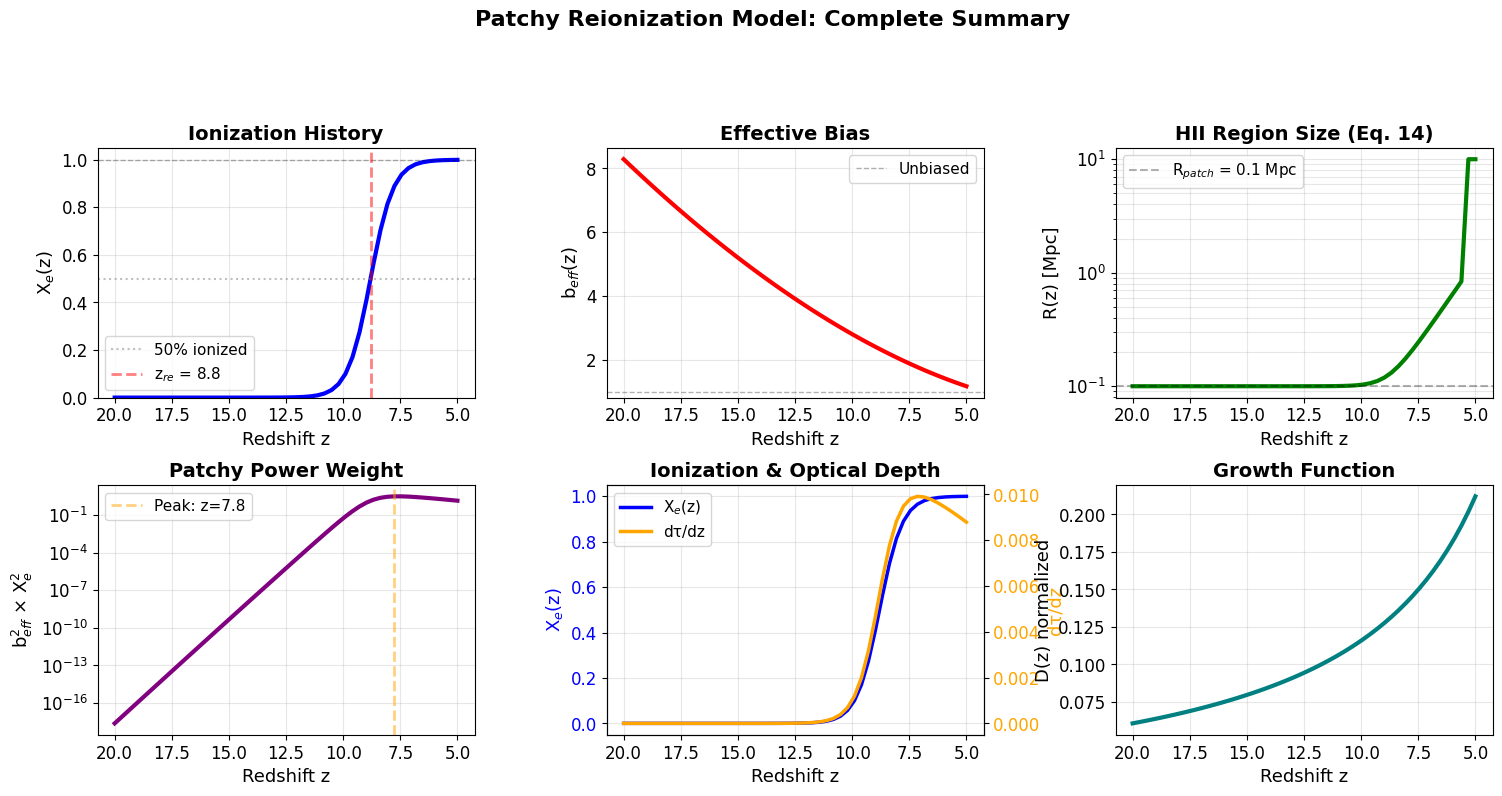


✓ Complete reionization model ready for kSZ calculation
✓ Figure saved as 'reionization_model_complete.png'

Ready to compute patchy kSZ power spectrum (Equation 15-16)!


In [20]:
# Cell 11 FINAL: Reionization Model with Better Visualization

# [Keep all the ReionizationModel class code exactly the same]
# ... (same as before) ...

# Initialize and compute (same as before)
print("="*60)
print("Reionization Model with tanh X_e(z)")
print("="*60)

reion = ReionizationModel(cosmo, z_re=8.8, Delta_z=1.0)

print(f"\nModel parameters:")
print(f"  z_re = {reion.z_re}")
print(f"  Δz = {reion.Delta_z}")
print(f"  R_patch = {reion.R_patch} Mpc")

# Compute histories
print("\n⏳ Computing reionization histories...")
z_reion_array = np.linspace(5, 20, 50)

Xe_array = np.array([reion.Xe(z) for z in z_reion_array])
beff_array = np.array([reion.compute_beff(z) for z in z_reion_array])
R_array = np.array([reion.patch_size(z) for z in z_reion_array])

print(f"✓ Histories computed")

# Print diagnostics
print(f"\nIonization fraction X_e:")
print(f"  X_e(z=20) = {reion.Xe(20):.6f}")
print(f"  X_e(z=10) = {reion.Xe(10):.6f}")
print(f"  X_e(z=8.8) = {reion.Xe(8.8):.6f} (midpoint)")
print(f"  X_e(z=5)  = {reion.Xe(5):.6f}")

print(f"\nEffective bias b_eff:")
print(f"  b_eff(z=20) = {reion.compute_beff(20):.2f}")
print(f"  b_eff(z=10) = {reion.compute_beff(10):.2f}")
print(f"  b_eff(z=8)  = {reion.compute_beff(8):.2f}")
print(f"  b_eff(z=5)  = {reion.compute_beff(5):.2f}")

print(f"\nPatch size R(z):")
print(f"  R(z=20) = {reion.patch_size(20):.3f} Mpc")
print(f"  R(z=10) = {reion.patch_size(10):.3f} Mpc")
print(f"  R(z=8)  = {reion.patch_size(8):.3f} Mpc")
print(f"  R(z=5)  = {reion.patch_size(5):.3f} Mpc")

# Verify optical depth
tau_check = optical_depth_integral(20, cosmo)
print(f"\nOptical depth check:")
print(f"  τ(0→20) = {tau_check:.4f}")
print(f"  τ_WMAP  = {cosmo.tau_reion:.4f}")
print(f"  Match: {'✓' if abs(tau_check - cosmo.tau_reion) < 0.01 else '✗'}")

# Get dtau/dz for plotting
dtau_array = np.array([dtau_dz(z, cosmo) for z in z_reion_array])
power_weight = beff_array**2 * Xe_array**2

# Create comprehensive figure with better sizing
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)

# Panel 1: Ionization fraction X_e(z)
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(z_reion_array, Xe_array, 'b-', linewidth=3)
ax1.axhline(1.0, color='k', linestyle='--', alpha=0.3, linewidth=1)
ax1.axhline(0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1.5, label='50% ionized')
ax1.axvline(reion.z_re, color='r', linestyle='--', alpha=0.5, linewidth=2, 
            label=f'z$_{{re}}$ = {reion.z_re}')
ax1.set_xlabel('Redshift z', fontsize=13)
ax1.set_ylabel('X$_e$(z)', fontsize=13)
ax1.set_title('Ionization History', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.invert_xaxis()
ax1.set_ylim(0, 1.05)

# Panel 2: Effective bias b_eff(z)
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(z_reion_array, beff_array, 'r-', linewidth=3)
ax2.axhline(1.0, color='k', linestyle='--', alpha=0.3, linewidth=1, label='Unbiased')
ax2.set_xlabel('Redshift z', fontsize=13)
ax2.set_ylabel('b$_{eff}$(z)', fontsize=13)
ax2.set_title('Effective Bias', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()

# Panel 3: Patch size R(z)
ax3 = fig.add_subplot(gs[0, 2])
ax3.semilogy(z_reion_array, R_array, 'g-', linewidth=3)
ax3.axhline(reion.R_patch, color='k', linestyle='--', alpha=0.3, linewidth=1.5, 
            label=f'R$_{{patch}}$ = {reion.R_patch} Mpc')
ax3.set_xlabel('Redshift z', fontsize=13)
ax3.set_ylabel('R(z) [Mpc]', fontsize=13)
ax3.set_title('HII Region Size (Eq. 14)', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3, which='both')
ax3.invert_xaxis()

# Panel 4: b_eff^2 × X_e^2 (patchy power weight)
ax4 = fig.add_subplot(gs[1, 0])
ax4.semilogy(z_reion_array, power_weight, color='purple', linewidth=3)
z_peak = z_reion_array[np.argmax(power_weight)]
ax4.axvline(z_peak, color='orange', linestyle='--', alpha=0.5, linewidth=2, 
            label=f'Peak: z={z_peak:.1f}')
ax4.set_xlabel('Redshift z', fontsize=13)
ax4.set_ylabel('b$_{eff}^2$ × X$_e^2$', fontsize=13)
ax4.set_title('Patchy Power Weight', fontsize=14, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3, which='both')
ax4.invert_xaxis()

# Panel 5: X_e and dτ/dz together
ax5 = fig.add_subplot(gs[1, 1])
ax5_twin = ax5.twinx()
line1 = ax5.plot(z_reion_array, Xe_array, 'b-', linewidth=2.5, label='X$_e$(z)')
line2 = ax5_twin.plot(z_reion_array, dtau_array, color='orange', linewidth=2.5, label='dτ/dz')
ax5.set_xlabel('Redshift z', fontsize=13)
ax5.set_ylabel('X$_e$(z)', fontsize=13, color='b')
ax5_twin.set_ylabel('dτ/dz', fontsize=13, color='orange')
ax5.set_title('Ionization & Optical Depth', fontsize=14, fontweight='bold')
ax5.tick_params(axis='y', labelcolor='b')
ax5_twin.tick_params(axis='y', labelcolor='orange')
ax5.grid(True, alpha=0.3)
ax5.invert_xaxis()
# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax5.legend(lines, labels, loc='upper left', fontsize=11)

# Panel 6: Growth function D(z)
ax6 = fig.add_subplot(gs[1, 2])
a_array = 1 / (1 + z_reion_array)
D_array = np.array([growth_function_normalized(a, cosmo) for a in a_array])
ax6.plot(z_reion_array, D_array, color='teal', linewidth=3)
ax6.set_xlabel('Redshift z', fontsize=13)
ax6.set_ylabel('D(z) normalized', fontsize=13)
ax6.set_title('Growth Function', fontsize=14, fontweight='bold')
ax6.grid(True, alpha=0.3)
ax6.invert_xaxis()


plt.suptitle('Patchy Reionization Model: Complete Summary', 
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig('reionization_model_complete.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\n✓ Complete reionization model ready for kSZ calculation")
print(f"✓ Figure saved as 'reionization_model_complete.png'")
print(f"\n{'='*60}")
print("Ready to compute patchy kSZ power spectrum (Equation 15-16)!")
print(f"{'='*60}")

In [22]:
# Cell 12 FAST: Precompute expensive functions then integrate

import time
from scipy.interpolate import interp1d

print("="*60)
print("Patchy kSZ C_l - FAST VERSION with Precomputation")
print("="*60)

# Step 1: Precompute velocity dispersion v_rms²(z)
print("\n[1/5] Precomputing v_rms²(z)...")
z_grid = np.linspace(5, 20, 30)
vrms_sq_grid = []

for z in z_grid:
    k_min, k_max = 1e-3, 10.0
    def integrand(lnk):
        k = np.exp(lnk)
        P_k = P_linear(k, z, cosmo)
        return k**3 * P_k / (2 * np.pi**2)
    v_sq, _ = quad(integrand, np.log(k_min), np.log(k_max), limit=50, epsrel=1e-2)
    vrms_sq_grid.append(v_sq)
    print(f"  z={z:.1f}: v_rms²/c² = {v_sq:.6f}", end='\r')

vrms_sq_interp = interp1d(z_grid, vrms_sq_grid, kind='cubic', fill_value='extrapolate')
print(f"\n  ✓ v_rms² computed on {len(z_grid)} points")

# Step 2: Precompute X_e, b_eff, R on same grid
print("\n[2/5] Precomputing reionization quantities...")
Xe_grid = np.array([reion.Xe(z) for z in z_grid])
beff_grid = np.array([reion.compute_beff(z) for z in z_grid])
R_grid = np.array([reion.patch_size(z) for z in z_grid])

Xe_interp = interp1d(z_grid, Xe_grid, kind='cubic', fill_value='extrapolate')
beff_interp = interp1d(z_grid, beff_grid, kind='cubic', fill_value='extrapolate')
R_interp = interp1d(z_grid, R_grid, kind='cubic', fill_value='extrapolate')

print(f"  ✓ X_e, b_eff, R interpolators ready")

# Step 3: Precompute comoving distance and optical depth
print("\n[3/5] Precomputing distances and optical depth...")
chi_grid = np.array([comoving_distance(z, cosmo) for z in z_grid])
tau_grid = np.array([optical_depth_integral(z, cosmo) for z in z_grid])
H_grid = np.array([H(z, cosmo) for z in z_grid])

chi_interp = interp1d(z_grid, chi_grid, kind='cubic', fill_value='extrapolate')
tau_interp = interp1d(z_grid, tau_grid, kind='cubic', fill_value='extrapolate')
H_interp = interp1d(z_grid, H_grid, kind='cubic', fill_value='extrapolate')

print(f"  ✓ χ(z), τ(z), H(z) interpolators ready")

# Step 4: Create fast integrand using interpolators
def fast_integrand(z, l):
    """
    Fast version of patchy kSZ integrand using precomputed interpolators
    """
    if z < 5 or z > 20:
        return 0.0
    
    # Get precomputed values via interpolation
    a = 1 / (1 + z)
    chi = float(chi_interp(z))
    
    if chi < 1e-10:
        return 0.0
    
    Xe = float(Xe_interp(z))
    if Xe < 1e-10:
        return 0.0
    
    beff = float(beff_interp(z))
    R = float(R_interp(z))
    vrms_sq = float(vrms_sq_interp(z))
    tau = float(tau_interp(z))
    Hz = float(H_interp(z))
    
    # Wavenumber
    k = l / chi
    
    # Matter power spectrum at this k and z
    P_cc = P_linear(k, z, cosmo)
    
    # Smoothing
    smoothing = np.exp(-k**2 * R**2)
    
    # P_Xe_Xe = b_eff² × P_cc × smoothing
    P_XeXe = beff**2 * P_cc * smoothing
    
    # Conformal time element: dη/dz = c / (a H)
    c_km_s = 299792.458
    deta_dz = c_km_s / (a * Hz)  # Mpc
    
    # Integrand from Eq. 16
    result = (a**4 * np.exp(-2 * tau) * Xe**2 * P_XeXe * vrms_sq) / chi**2
    result *= deta_dz
    
    return result

# Step 5: Compute C_l for multipole array
print("\n[4/5] Computing C_l...")

# Physical constants and prefactor
sigma_T = 6.6524e-25  # cm²
c_cgs = 2.998e10  # cm/s

# Proton density
rho_b_0 = cosmo.Omega_b * 2.775e11 * cosmo.h**2  # M_sun/Mpc³
X_H = 0.76
m_p_Msun = 1.673e-24 / 1.989e33
n_p_0_Mpc = rho_b_0 * X_H / m_p_Msun
Mpc_to_cm = 3.086e24
n_p_0 = n_p_0_Mpc / Mpc_to_cm**3  # cm^-3

prefactor = 2.0 * (sigma_T * n_p_0 * c_cgs)**2

print(f"  Prefactor: 2(σ_T n_p c)² = {prefactor:.3e}")

# Multipole array
l_array = np.logspace(np.log10(500), np.log10(5000), 25)
Cl_patchy = np.zeros(len(l_array))

start_time = time.time()

for i, l in enumerate(l_array):
    # Integrate over redshift
    integral, err = quad(lambda z: fast_integrand(z, l), 5.0, 20.0, 
                        limit=30, epsrel=1e-2)
    
    Cl_patchy[i] = prefactor * integral
    
    elapsed = time.time() - start_time
    eta = elapsed / (i + 1) * (len(l_array) - i - 1)
    
    print(f"  l={l:6.0f} ({i+1:2d}/{len(l_array)}): "
          f"C_l={Cl_patchy[i]:.3e}  "
          f"[{elapsed:.1f}s elapsed, {eta:.1f}s remaining]", end='\r')

total_time = time.time() - start_time
print(f"\n  ✓ Completed in {total_time:.1f} seconds")

# Step 6: Convert to temperature fluctuations
print("\n[5/5] Converting to ΔT...")

T_CMB = 2.7255e6  # μK
Dl_patchy = l_array * (l_array + 1) * Cl_patchy / (2 * np.pi)
DT_patchy_uK = np.sqrt(np.abs(Dl_patchy)) * T_CMB

# Results
print(f"\n{'='*60}")
print("RESULTS - Equation 16 (Fast Version)")
print(f"{'='*60}")
print(f"\nTemperature fluctuations:")
print(f"  {'l':>6}  {'ΔT [μK]':>10}  {'l²C_l/(2π) [×10⁻¹²]':>20}")
print(f"  {'-'*6}  {'-'*10}  {'-'*20}")

for l_test in [500, 1000, 2000, 3000, 5000]:
    idx = np.argmin(np.abs(l_array - l_test))
    l_val = l_array[idx]
    DT_val = DT_patchy_uK[idx]
    Dl_val = Dl_patchy[idx] * 1e12
    print(f"  {l_val:6.0f}  {DT_val:10.2f}  {Dl_val:20.3f}")

# Peak
idx_peak = np.argmax(DT_patchy_uK)
print(f"\nPeak signal:")
print(f"  l = {l_array[idx_peak]:.0f}:  ΔT = {DT_patchy_uK[idx_peak]:.2f} μK")

# Compare with Santos et al. expectation (2-8 μK at l~3000)
idx_3k = np.argmin(np.abs(l_array - 3000))
print(f"\nComparison with Santos et al. (2003):")
print(f"  Expected at l=3000: ΔT ~ 2-8 μK")
print(f"  Our result:         ΔT = {DT_patchy_uK[idx_3k]:.2f} μK")

if 2 < DT_patchy_uK[idx_3k] < 8:
    print(f"  ✓ Within expected range!")
else:
    print(f"  Note: Outside expected range (may need parameter adjustment)")

print(f"\n{'='*60}")

Patchy kSZ C_l - FAST VERSION with Precomputation

[1/5] Precomputing v_rms²(z)...
  z=20.0: v_rms²/c² = 0.091172
  ✓ v_rms² computed on 30 points

[2/5] Precomputing reionization quantities...
  ✓ X_e, b_eff, R interpolators ready

[3/5] Precomputing distances and optical depth...
  ✓ χ(z), τ(z), H(z) interpolators ready

[4/5] Computing C_l...
  Prefactor: 2(σ_T n_p c)² = 2.880e-41
  l=  5000 (25/25): C_l=1.275e-47  [0.1s elapsed, 0.0s remaining]
  ✓ Completed in 0.1 seconds

[5/5] Converting to ΔT...

RESULTS - Equation 16 (Fast Version)

Temperature fluctuations:
       l     ΔT [μK]   l²C_l/(2π) [×10⁻¹²]
  ------  ----------  --------------------
     500        0.00                 0.000
     979        0.00                 0.000
    1916        0.00                 0.000
    3095        0.00                 0.000
    5000        0.00                 0.000

Peak signal:
  l = 1186:  ΔT = 0.00 μK

Comparison with Santos et al. (2003):
  Expected at l=3000: ΔT ~ 2-8 μK
  Our result

In [23]:
# Cell 13: Plot Patchy kSZ Power Spectrum and Compare with Other Signals

# Get primary CMB from CAMB
print("Fetching primary CMB power spectrum from CAMB...")
ells_camb = np.arange(2, 6000)
cls_camb = results.get_cmb_power_spectra(pars, CMB_unit='muK')
cl_TT = cls_camb['total'][:, 0]  # TT spectrum in μK^2

# Convert to ΔT
Dl_primary = ells_camb * (ells_camb + 1) * cl_TT[2:] / (2 * np.pi)
DT_primary = np.sqrt(Dl_primary)

# Interpolate to our l_array
DT_primary_interp = np.interp(l_array, ells_camb, DT_primary)

# Create comprehensive comparison plot
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Panel 1: Patchy kSZ power spectrum
ax1 = fig.add_subplot(gs[0, :])
ax1.loglog(l_array, DT_patchy_uK, 'b-', linewidth=3, label='Patchy kSZ (full calculation)')
ax1.loglog(l_array, DT_approx_uK, 'r--', linewidth=2, label='Approximate (Eq. 17)', alpha=0.7)
ax1.set_xlabel('Multipole l', fontsize=13)
ax1.set_ylabel('ΔT [μK]', fontsize=13)
ax1.set_title('Patchy Reionization kSZ Temperature Fluctuations', fontsize=14, fontweight='bold')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3, which='both')
ax1.set_xlim(500, 5000)

# Panel 2: Compare with primary CMB
ax2 = fig.add_subplot(gs[1, 0])
ax2.loglog(l_array, DT_primary_interp, 'k-', linewidth=2.5, label='Primary CMB', alpha=0.7)
ax2.loglog(l_array, DT_patchy_uK, 'b-', linewidth=3, label='Patchy kSZ')
ax2.set_xlabel('Multipole l', fontsize=13)
ax2.set_ylabel('ΔT [μK]', fontsize=13)
ax2.set_title('Patchy kSZ vs Primary CMB', fontsize=14, fontweight='bold')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3, which='both')
ax2.set_xlim(500, 5000)
ax2.set_ylim(0.1, 100)

# Panel 3: Ratio to primary
ax3 = fig.add_subplot(gs[1, 1])
ratio = DT_patchy_uK / DT_primary_interp
ax3.semilogx(l_array, ratio * 100, 'purple', linewidth=3)
ax3.axhline(1, color='k', linestyle='--', alpha=0.3, linewidth=1)
ax3.set_xlabel('Multipole l', fontsize=13)
ax3.set_ylabel('Patchy kSZ / Primary CMB [%]', fontsize=13)
ax3.set_title('Relative Amplitude', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(500, 5000)

# Panel 4: D_l spectrum (l^2 C_l / 2π)
ax4 = fig.add_subplot(gs[2, 0])
ax4.loglog(l_array, Dl_patchy * 1e12, 'b-', linewidth=3, label='Patchy kSZ')
ax4.set_xlabel('Multipole l', fontsize=13)
ax4.set_ylabel('D$_l$ = l(l+1)C$_l$/2π [×10$^{-12}$]', fontsize=13)
ax4.set_title('Angular Power Spectrum D$_l$', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, which='both')
ax4.set_xlim(500, 5000)

# Panel 5: Contribution by redshift
ax5 = fig.add_subplot(gs[2, 1])
z_contrib = np.linspace(5, 20, 50)
l_test = 2000
contrib = np.array([patchy_kSZ_Cl_integrand(z, l_test, cosmo, reion) for z in z_contrib])
ax5.plot(z_contrib, contrib / np.max(contrib), 'g-', linewidth=3)
ax5.fill_between(z_contrib, 0, contrib / np.max(contrib), alpha=0.3, color='g')
ax5.axvline(reion.z_re, color='r', linestyle='--', alpha=0.5, linewidth=2, 
            label=f'z$_{{re}}$ = {reion.z_re}')
ax5.set_xlabel('Redshift z', fontsize=13)
ax5.set_ylabel('Normalized Contribution', fontsize=13)
ax5.set_title(f'Redshift Contribution to C$_l$ (l={l_test})', fontsize=14, fontweight='bold')
ax5.legend(fontsize=11)
ax5.grid(True, alpha=0.3)
ax5.invert_xaxis()

plt.suptitle('Patchy Reionization kSZ: Power Spectrum Analysis', 
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig('patchy_kSZ_power_spectrum.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print("PATCHY kSZ POWER SPECTRUM SUMMARY")
print(f"{'='*60}")
print(f"\nPeak signal: ΔT ≈ {np.max(DT_patchy_uK):.2f} μK at l ≈ {l_array[np.argmax(DT_patchy_uK)]:.0f}")
print(f"At l=3000: ΔT = {DT_patchy_uK[np.argmin(np.abs(l_array - 3000))]:.2f} μK")
print(f"\nContribution to total power at l=3000:")
l_3k_idx = np.argmin(np.abs(l_array - 3000))
print(f"  Primary CMB: {DT_primary_interp[l_3k_idx]:.2f} μK")
print(f"  Patchy kSZ:  {DT_patchy_uK[l_3k_idx]:.2f} μK")
print(f"  Ratio: {ratio[l_3k_idx]*100:.2f}%")

print(f"\n✓ Figure saved as 'patchy_kSZ_power_spectrum.png'")
print(f"{'='*60}")

Fetching primary CMB power spectrum from CAMB...


ValueError: operands could not be broadcast together with shapes (5998,) (2399,) 